In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visual style
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'sans-serif'

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# Load the dataset
df = pd.read_csv('C:/Users/T470/OneDrive/Desktop/sa-labour-analysis/HRDataset_v14.csv')

# Basic info
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (311, 36)

Columns: ['Employee_Name', 'EmpID', 'MarriedID', 'MaritalStatusID', 'GenderID', 'EmpStatusID', 'DeptID', 'PerfScoreID', 'FromDiversityJobFairID', 'Salary', 'Termd', 'PositionID', 'Position', 'State', 'Zip', 'DOB', 'Sex', 'MaritalDesc', 'CitizenDesc', 'HispanicLatino', 'RaceDesc', 'DateofHire', 'DateofTermination', 'TermReason', 'EmploymentStatus', 'Department', 'ManagerName', 'ManagerID', 'RecruitmentSource', 'PerformanceScore', 'EngagementSurvey', 'EmpSatisfaction', 'SpecialProjectsCount', 'LastPerformanceReview_Date', 'DaysLateLast30', 'Absences']

First 5 rows:


,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2


In [3]:
# Data overview
print("Dataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
df[['Salary', 'Absences', 'EmpSatisfaction', 'EngagementSurvey']].describe()

Dataset Shape: (311, 36)

Data Types:
Employee_Name                     str
EmpID                           int64
MarriedID                       int64
MaritalStatusID                 int64
GenderID                        int64
EmpStatusID                     int64
DeptID                          int64
PerfScoreID                     int64
FromDiversityJobFairID          int64
Salary                          int64
Termd                           int64
PositionID                      int64
Position                          str
State                             str
Zip                             int64
DOB                               str
Sex                               str
MaritalDesc                       str
CitizenDesc                       str
HispanicLatino                    str
RaceDesc                          str
DateofHire                        str
DateofTermination                 str
TermReason                        str
EmploymentStatus                  str
Department  

,Salary,Absences,EmpSatisfaction,EngagementSurvey
count,311.000000,311.000000,311.000000,311.000000
mean,69020.684887,10.237942,3.890675,4.110000
std,25156.636930,5.852596,0.909241,0.789938
min,45046.000000,1.000000,1.000000,1.120000
25%,55501.500000,5.000000,3.000000,3.690000
50%,62810.000000,10.000000,4.000000,4.280000
75%,72036.000000,15.000000,5.000000,4.700000
max,250000.000000,20.000000,5.000000,5.000000


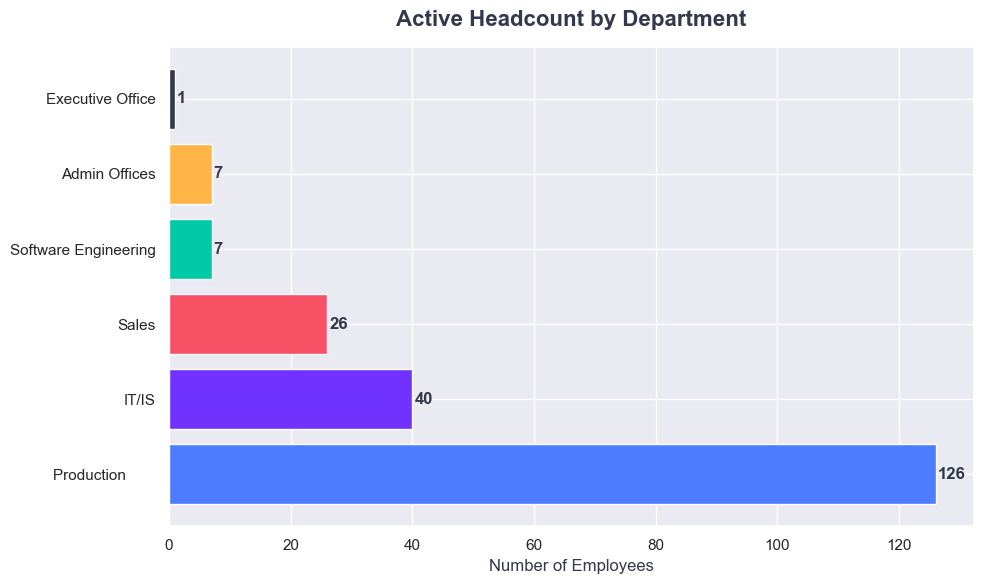

Chart saved!


In [4]:
# Headcount by Department
active = df[df['EmploymentStatus'] == 'Active']

plt.figure(figsize=(10, 6))
dept_counts = active['Department'].value_counts()
colors = ['#4E7CFF', '#7033FF', '#F65164', '#00C9A7', '#FFB547', '#33394C']

bars = plt.barh(dept_counts.index, dept_counts.values, color=colors)

# Add value labels
for bar, val in zip(bars, dept_counts.values):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontweight='bold', color='#33394C')

plt.title('Active Headcount by Department', fontsize=16, fontweight='bold', color='#33394C', pad=15)
plt.xlabel('Number of Employees', color='#33394C')
plt.tight_layout()
plt.savefig('C:/Users/T470/OneDrive/Desktop/sa-labour-analysis/chart1_headcount.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

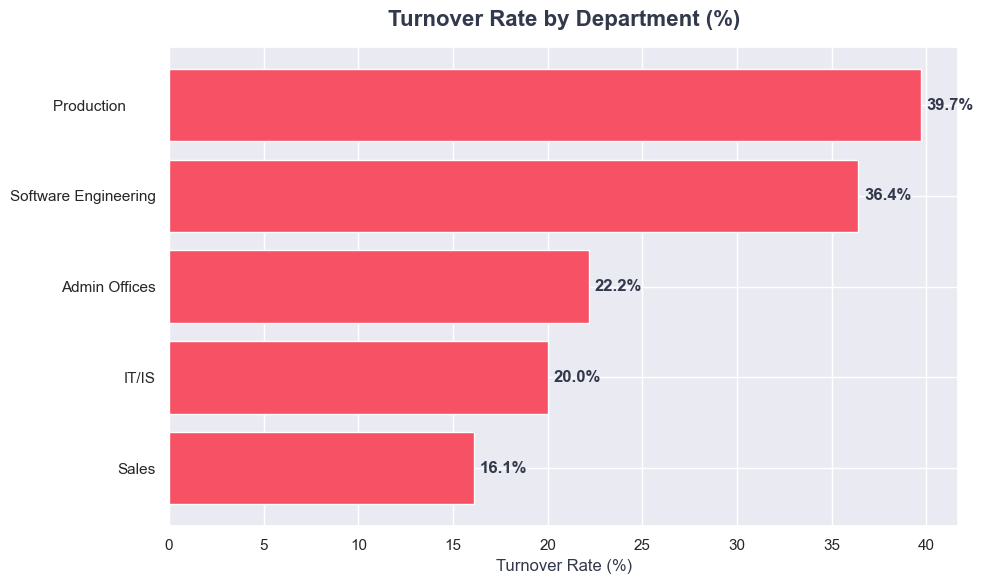

Chart saved!


In [5]:
# Turnover Rate by Department
dept_total = df.groupby('Department').size()
dept_termed = df[df['EmploymentStatus'] != 'Active'].groupby('Department').size()
turnover = (dept_termed / dept_total * 100).round(1).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(turnover.index, turnover.values, color='#F65164')

for bar, val in zip(bars, turnover.values):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val}%', va='center', fontweight='bold', color='#33394C')

plt.title('Turnover Rate by Department (%)', fontsize=16, fontweight='bold', color='#33394C', pad=15)
plt.xlabel('Turnover Rate (%)', color='#33394C')
plt.tight_layout()
plt.savefig('C:/Users/T470/OneDrive/Desktop/sa-labour-analysis/chart2_turnover.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

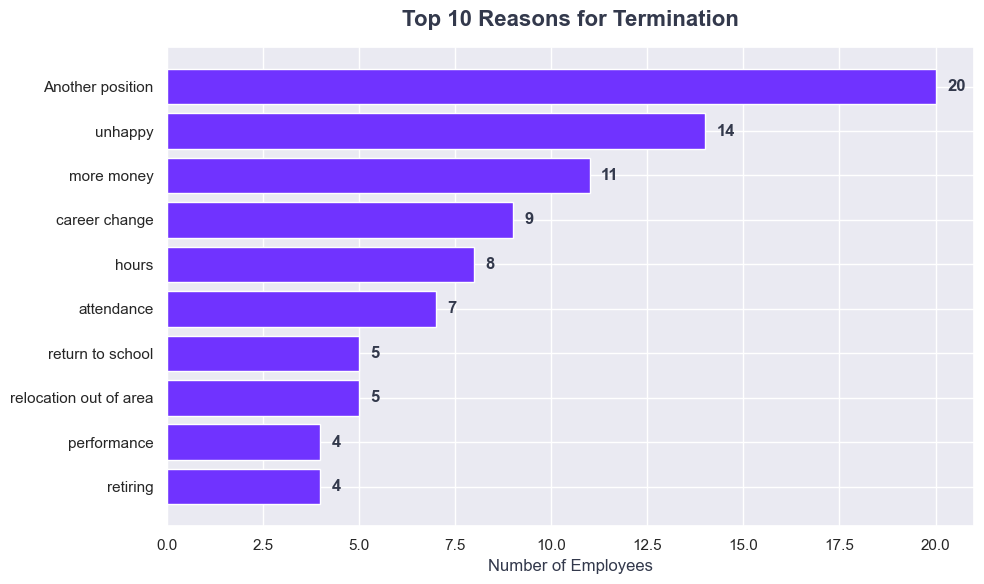

Chart saved!


In [6]:
# Top Termination Reasons
termed = df[df['EmploymentStatus'] != 'Active']
term_reasons = termed['TermReason'].value_counts().head(10)

plt.figure(figsize=(10, 6))
bars = plt.barh(term_reasons.index[::-1], term_reasons.values[::-1], color='#7033FF')

for bar, val in zip(bars, term_reasons.values[::-1]):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontweight='bold', color='#33394C')

plt.title('Top 10 Reasons for Termination', fontsize=16, fontweight='bold', color='#33394C', pad=15)
plt.xlabel('Number of Employees', color='#33394C')
plt.tight_layout()
plt.savefig('C:/Users/T470/OneDrive/Desktop/sa-labour-analysis/chart3_termination_reasons.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

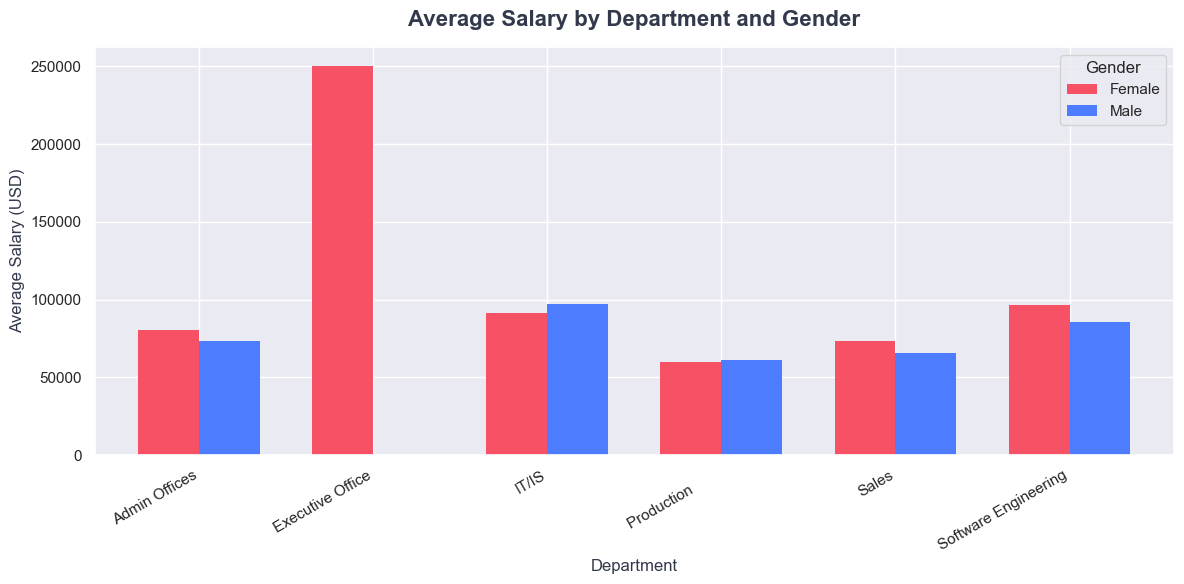

Chart saved!


In [7]:
# Average Salary by Department and Gender
salary_gender = df[df['EmploymentStatus'] == 'Active'].groupby(
    ['Department', 'Sex'])['Salary'].mean().round(0).unstack()

ax = salary_gender.plot(kind='bar', figsize=(12, 6), 
                         color=['#F65164', '#4E7CFF'], 
                         width=0.7, edgecolor='none')

plt.title('Average Salary by Department and Gender', fontsize=16, 
          fontweight='bold', color='#33394C', pad=15)
plt.xlabel('Department', color='#33394C')
plt.ylabel('Average Salary (USD)', color='#33394C')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Gender', labels=['Female', 'Male'])
plt.tight_layout()
plt.savefig('C:/Users/T470/OneDrive/Desktop/sa-labour-analysis/chart4_salary_gender.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

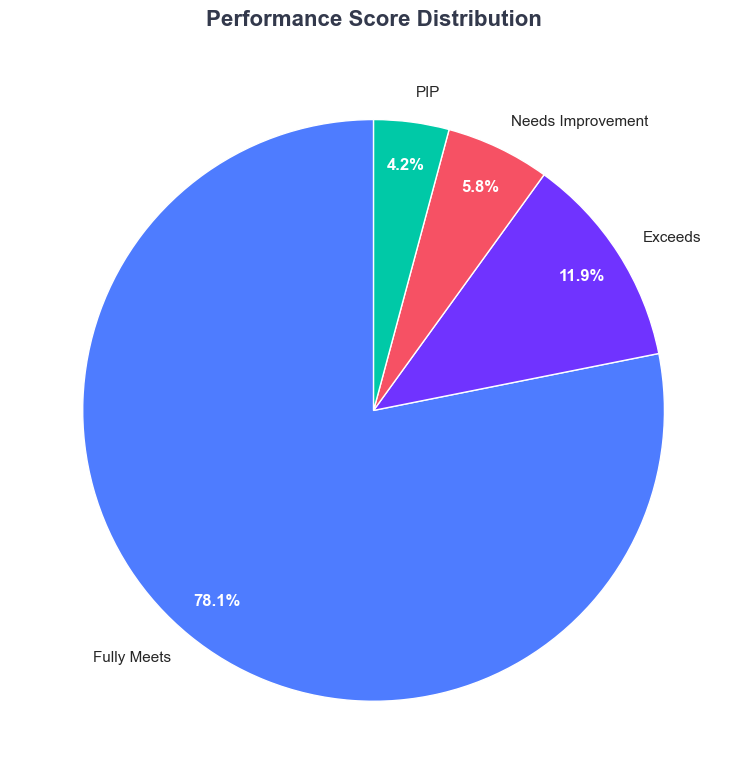

Chart saved!


In [8]:
# Performance Score Distribution
perf = df['PerformanceScore'].value_counts()

plt.figure(figsize=(8, 8))
colors = ['#4E7CFF', '#7033FF', '#F65164', '#00C9A7']
wedges, texts, autotexts = plt.pie(
    perf.values, 
    labels=perf.index, 
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    pctdistance=0.85
)

for text in autotexts:
    text.set_fontweight('bold')
    text.set_color('white')

plt.title('Performance Score Distribution', fontsize=16, 
          fontweight='bold', color='#33394C', pad=15)
plt.tight_layout()
plt.savefig('C:/Users/T470/OneDrive/Desktop/sa-labour-analysis/chart5_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

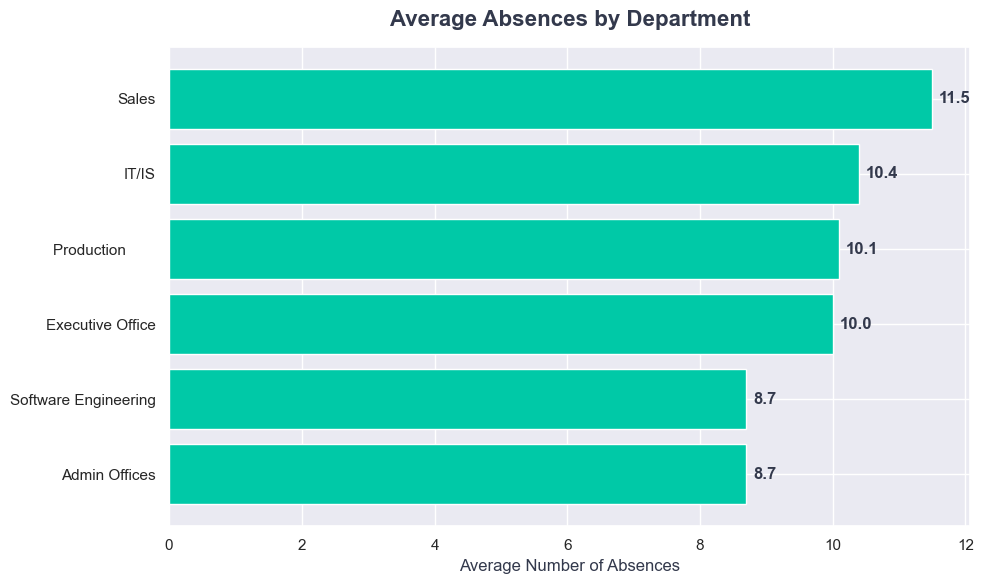

Chart saved!


In [9]:
# Average Absences by Department
absences = df.groupby('Department')['Absences'].mean().round(1).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(absences.index, absences.values, color='#00C9A7')

for bar, val in zip(bars, absences.values):
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontweight='bold', color='#33394C')

plt.title('Average Absences by Department', fontsize=16, 
          fontweight='bold', color='#33394C', pad=15)
plt.xlabel('Average Number of Absences', color='#33394C')
plt.tight_layout()
plt.savefig('C:/Users/T470/OneDrive/Desktop/sa-labour-analysis/chart6_absences.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

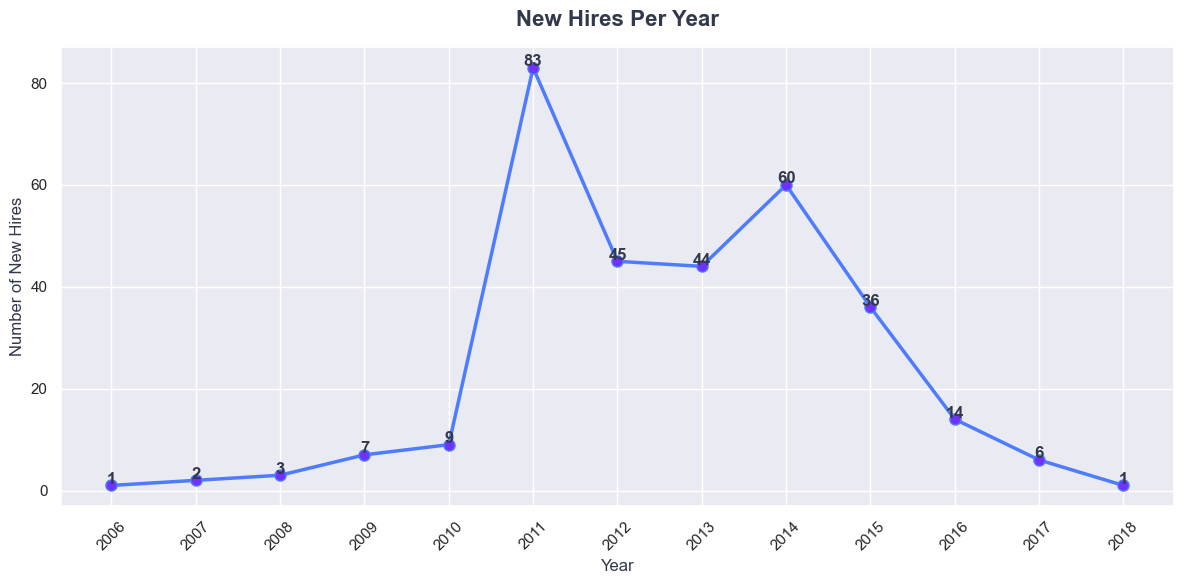

Chart saved!


In [10]:
# Hiring Trend Over Time
df['DateofHire'] = pd.to_datetime(df['DateofHire'])
df['HireYear'] = df['DateofHire'].dt.year
hires_per_year = df.groupby('HireYear').size()

plt.figure(figsize=(12, 6))
plt.plot(hires_per_year.index, hires_per_year.values, 
         color='#4E7CFF', linewidth=2.5, marker='o', 
         markersize=8, markerfacecolor='#7033FF')

# Add value labels
for x, y in zip(hires_per_year.index, hires_per_year.values):
    plt.text(x, y + 0.3, str(y), ha='center', 
             fontweight='bold', color='#33394C')

plt.title('New Hires Per Year', fontsize=16, 
          fontweight='bold', color='#33394C', pad=15)
plt.xlabel('Year', color='#33394C')
plt.ylabel('Number of New Hires', color='#33394C')
plt.xticks(hires_per_year.index, rotation=45)
plt.tight_layout()
plt.savefig('C:/Users/T470/OneDrive/Desktop/sa-labour-analysis/chart7_hiring_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [11]:
# Key Insights Summary
active_count = df[df['EmploymentStatus'] == 'Active'].shape[0]
termed_count = df[df['EmploymentStatus'] != 'Active'].shape[0]
turnover_rate = round(termed_count / df.shape[0] * 100, 1)
avg_salary = round(df[df['EmploymentStatus'] == 'Active']['Salary'].mean(), 0)
top_term_reason = df[df['EmploymentStatus'] != 'Active']['TermReason'].value_counts().index[0]
highest_turnover_dept = (df[df['EmploymentStatus'] != 'Active'].groupby('Department').size() / 
                          df.groupby('Department').size() * 100).round(1).idxmax()

print("=" * 50)
print("   HR ANALYTICS — KEY INSIGHTS")
print("=" * 50)
print(f"Total Employees        : {df.shape[0]}")
print(f"Active Employees       : {active_count}")
print(f"Terminated Employees   : {termed_count}")
print(f"Overall Turnover Rate  : {turnover_rate}%")
print(f"Average Active Salary  : ${avg_salary:,.0f}")
print(f"Top Termination Reason : {top_term_reason}")
print(f"Highest Turnover Dept  : {highest_turnover_dept}")
print("=" * 50)

   HR ANALYTICS — KEY INSIGHTS
Total Employees        : 311
Active Employees       : 207
Terminated Employees   : 104
Overall Turnover Rate  : 33.4%
Average Active Salary  : $70,694
Top Termination Reason : Another position
Highest Turnover Dept  : Production       
